# Examen Final — Programación 1 (F12)
## Análisis de Datos Sísmicos con la API del USGS

**Nombre:** Ilsy Castillo 
**Carnet:** 202005371  
**Fecha:** 18 de mayo de 2026  
**Punteo total:** 100 puntos

---

| Ejercicio | Tema | Puntos |
|---|---|:---:|
| 1a | Cargar datos con `pd.read_csv()` desde URL | 10 |
| 1b | Explorar el DataFrame con un ciclo `for` | 10 |
| 2a | Encontrar el sismo más intenso con un ciclo `for` | 10 |
| 2b | Top 5 sismos más profundos con pandas | 10 |
| 3a | Función `clasificar_sismo()` con condicionales | 15 |
| 3b | Agregar columna de categoría y agrupar con `groupby` | 10 |
| 4a | Función `analizar_sismos()` que retorna un diccionario | 15 |
| 4b | Tres visualizaciones con matplotlib/seaborn | 20 |
| | **Total** | **100** |

---

> **Instrucciones generales**
> - Completa cada ejercicio en la celda indicada.
> - Ejecuta las celdas **en orden** de arriba hacia abajo.
> - Puedes consultar tus apuntes y el enunciado del examen en U Virtual.
> - Entrega el notebook con **todas las celdas ejecutadas** (con output visible).
> - Sube el archivo a tu repositorio en GitHub y envía el enlace a U Virtual.


---
## Contexto: ¿Qué es un terremoto y cómo se mide?

Un **terremoto** ocurre cuando dos placas tectónicas se deslizan bruscamente entre sí,
liberando energía en forma de ondas sísmicas que se propagan por la tierra.

### Magnitud — escala de intensidad

La magnitud mide la energía liberada. La relación es **logarítmica**:
un sismo de magnitud 7.0 libera ~32 veces más energía que uno de 6.0.

| Magnitud | Categoría | Frecuencia aproximada (global) |
|---|---|---|
| < 5.5 | Ligero | Miles por año |
| 5.5 – 5.9 | Moderado-Fuerte | ~500 por año |
| 6.0 – 6.9 | Fuerte | ~130 por año |
| 7.0 – 7.9 | Mayor | ~15 por año |
| ≥ 8.0 | Gran terremoto | 1–2 por año |

### Profundidad del foco

La **profundidad** (columna `depth`) indica dónde ocurrió la ruptura:
- **Superficial** (< 70 km): generalmente más destructivo
- **Intermedio** (70–300 km): daños moderados
- **Profundo** (> 300 km): raramente destructivo en superficie


---
## El dataset: USGS Earthquake Catalog

**Fuente:** United States Geological Survey — [earthquake.usgs.gov](https://earthquake.usgs.gov)

El USGS monitorea la actividad sísmica global en tiempo real y publica todos los
registros de forma abierta. Su API permite descargar datos históricos directamente
como CSV, **sin necesidad de API key**.

Los datos de este examen contienen todos los sismos de **magnitud ≥ 5.5 registrados
en el primer semestre de 2024** (aproximadamente 700 eventos).

### Columnas principales

| Columna | Tipo | Descripción |
|---|---|---|
| `time` | str | Fecha y hora UTC del evento |
| `mag` | float | Magnitud del sismo |
| `depth` | float | Profundidad del foco en kilómetros |
| `magType` | str | Escala usada (`mww`, `mb`, `ml`, …) |
| `place` | str | Descripción de la ubicación |
| `latitude` | float | Latitud del epicentro |
| `longitude` | float | Longitud del epicentro |

### URL del dataset

```
https://earthquake.usgs.gov/fdsnws/event/1/query
    ?format=csv
    &starttime=2024-01-01
    &endtime=2024-06-30
    &minmagnitude=5.5
```

> `pd.read_csv()` acepta URLs directamente — no necesitas descargar el archivo.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context


URL_SISMOS = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query"
    "?format=csv"
    "&starttime=2024-01-01"
    "&endtime=2024-06-30"
    "&minmagnitude=5.5"
)

print("Librerias importadas correctamente.")
print(f"URL: {URL_SISMOS}")


Librerias importadas correctamente.
URL: https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2024-01-01&endtime=2024-06-30&minmagnitude=5.5


---
## Identificación del estudiante

Completa tu nombre y carnet en la siguiente celda y **ejecútala antes de comenzar**.


In [3]:
# Completa tus datos
NOMBRE = "Ilsy Castillo"   # TU NOMBRE AQUI
CARNET = "202005371"         # TU CARNET AQUI

if NOMBRE == "Nombre Apellito" or CARNET == "202300000":
    raise ValueError("Completa tu nombre y carnet antes de continuar.")

print(f"Estudiante : {NOMBRE}")
print(f"Carnet     : {CARNET}")


Estudiante : Ilsy Castillo
Carnet     : 202005371


---
## Ejercicio 1 — Cargar y explorar los datos (20 pts)

### Parte a) — Cargar el CSV desde la URL (10 pts)

`pandas.read_csv()` puede cargar datos directamente desde una URL,
igual que desde un archivo local. El resultado es un **DataFrame**.

Carga los datos usando `URL_SISMOS` (ya definida arriba) y guárdalos en la
variable `sismos`. Luego muestra:
- Las primeras 5 filas con `.head()`
- Las dimensiones con `.shape`
- Los tipos de datos con `.dtypes`
- Los valores nulos con `.isnull().sum()`


In [6]:
# Carga el CSV desde URL_SISMOS con pd.read_csv() y guárdalo en 'sismos'

sismos = pd.read_csv(URL_SISMOS)

# Muestra las primeras 5 filas
# TU CÓDIGO AQUÍ
print("Primeras cinco filas:")
print(sismos.head())

# Muestra las dimensiones (shape)
# TU CÓDIGO AQUÍ
print(f"\nDimensiones: {sismos.shape}")


# Muestra los tipos de datos (dtypes)
# TU CÓDIGO AQUÍ

print(f"\nTipos de datos:")
print(sismos.dtypes)

# Verifica valores nulos con isnull().sum()
# TU CÓDIGO AQUÍ
print(f"\nValores nulos:")
print(sismos.isnull().sum())

Primeras cinco filas:
                       time  latitude  longitude  depth  mag magType    nst  \
0  2024-06-29T16:38:46.516Z  -54.0633     7.2302   10.0  5.6     mww  209.0   
1  2024-06-29T07:05:32.855Z  -16.0485   -74.5560   18.0  6.1     mww  138.0   
2  2024-06-28T13:00:39.570Z  -20.6490  -175.6315   10.0  5.7     mww   75.0   
3  2024-06-28T05:36:36.902Z  -15.8277   -74.4540   24.0  7.2     mww  105.0   
4  2024-06-27T16:37:51.299Z  -33.4081  -179.2724   29.0  5.9     mww   95.0   

    gap    dmin   rms  ...                   updated  \
0  16.0  18.209  0.88  ...  2024-09-04T21:57:44.040Z   
1  89.0   4.606  0.71  ...  2024-09-04T21:57:44.040Z   
2  38.0   0.654  0.65  ...  2024-10-09T03:15:27.209Z   
3  46.0   4.675  0.93  ...  2025-02-09T14:16:45.954Z   
4  56.0   4.292  1.05  ...  2024-09-04T21:57:42.040Z   

                           place        type horizontalError depthError  \
0           Bouvet Island region  earthquake            8.89      1.193   
1     34 km SW o

### Parte b) — Explorar con un ciclo `for` (10 pts)

Usando un ciclo `for` y el método
[`.iterrows()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html),
imprime la información de los **primeros 5 sismos** en este formato:

```
Sismo 1: mag=6.10 | prof=35.0 km | lugar=Southern Sumatra, Indonesia
Sismo 2: mag=5.80 | prof=10.0 km | lugar=...
...
```

> **¿Por qué iterar sobre un DataFrame?**  
> Aunque pandas vectoriza la mayoría de operaciones, los ciclos `for` sobre filas
> son útiles cuando necesitas lógica condicional compleja por fila o procesar
> cada elemento de forma independiente.


In [15]:
# Hint: .iterrows() devuelve pares (indice, fila) donde 'fila' es una Serie
# Hint: accede a los valores con fila['mag'], fila['depth'], fila['place']
# Hint: usa enumerate() o un contador para detener el ciclo en 5

contador = 0
for indice, fila in sismos.iterrows():
    if contador >= 5:
        break
    # TU CÓDIGO AQUÍ — imprime mag, depth y place de esta fila


    contador += 1
    print("Primeros cinco sismos usando ciclo for:\n")

for indice, fila in sismos.head(5).iterrows():
    print(f"Índice {indice}:")
    print(f"  Lugar: {fila['place']}")
    print(f"  Magnitud: {fila['mag']}")
    print(f"  Profundidad: {fila['depth']} km")
    print(f"  Tipo de escala: {fila['magType']}")



Primeros cinco sismos usando ciclo for:

Primeros cinco sismos usando ciclo for:

Primeros cinco sismos usando ciclo for:

Primeros cinco sismos usando ciclo for:

Primeros cinco sismos usando ciclo for:

Índice 0:
  Lugar: Bouvet Island region
  Magnitud: 5.6
  Profundidad: 10.0 km
  Tipo de escala: mww
Índice 1:
  Lugar: 34 km SW of Atiquipa, Peru
  Magnitud: 6.1
  Profundidad: 18.0 km
  Tipo de escala: mww
Índice 2:
  Lugar: 67 km NNW of Houma, Tonga
  Magnitud: 5.7
  Profundidad: 10.0 km
  Tipo de escala: mww
Índice 3:
  Lugar: 10 km WSW of Atiquipa, Peru
  Magnitud: 7.2
  Profundidad: 24.0 km
  Tipo de escala: mww
Índice 4:
  Lugar: south of the Kermadec Islands
  Magnitud: 5.9
  Profundidad: 29.0 km
  Tipo de escala: mww


---
## Ejercicio 2 — Encontrar los extremos (20 pts)

### Parte a) — Sismo más intenso con ciclo `for` (10 pts)

Usando **únicamente** un ciclo `for` y un `if`, itera sobre la columna `mag`
y encuentra el sismo con la **mayor magnitud**.
Guarda el índice y la magnitud máxima encontrada, luego imprime los datos
completos de ese sismo (place, mag, depth, magType).

### Parte b) — Top 5 más profundos con pandas (10 pts)

Usa `.sort_values()` + `.head()` para encontrar los **5 sismos más profundos**.
Muestra solo las columnas `place`, `mag`, `depth` y `magType`.
Luego verifica que el sismo encontrado en la Parte a) aparece en el top 5
de magnitudes (usa también `.sort_values()` + `.head()`).


In [25]:
# ── Parte a) — ciclo for ─────────────────────────────────────────────────────
# Hint: necesitas dos variables auxiliares:
#   mag_max   = 0     (para ir guardando el mayor encontrado)
#   idx_max   = None  (para recordar el índice de esa fila)

mag_max = 0
idx_max = None

for idx, mag in enumerate(sismos['mag']):

    
    # TU CÓDIGO AQUÍ — actualiza mag_max e idx_max si encontraste uno mayor
    pass

print("sismo más intenso")

max_magnitud = -1
sismo_max_indice = None
sismo_max_fila = None

for indice, fila in sismos.iterrows():
    if fila['mag'] > max_magnitud:
        max_magnitud = fila['mag']
        sismo_max_indice = indice
        sismo_max_fila = fila

print(f"Sismo más intenso encontrado:")
print(f"  Magnitud: {sismo_max_fila['mag']:.2f}")
print(f"  Lugar: {sismo_max_fila['place']}")
print(f"  Profundidad: {sismo_max_fila['depth']:.2f} km")
print(f"  Fecha: {sismo_max_fila['time']}")


# ── Parte b) — pandas ─────────────────────────────────────────────────────────
print("\nTop 5 sismos más profundos:")
# TU CÓDIGO AQUÍ — sort_values por 'depth' descendente + head(5)

print("Top 5 sismos más profundos:\n")

# Ordenar por profundidad (descendente) y tomar top 5
top5_profundos = sismos.sort_values(by='depth', ascending=False).head(5)

for i, (indice, fila) in enumerate(top5_profundos.iterrows(), 1):
    print(f"{i}. Profundidad: {fila['depth']:.1f} km | "
          f"Magnitud: {fila['mag']:.1f} | {fila['place']}")


sismo más intenso
Sismo más intenso encontrado:
  Magnitud: 7.50
  Lugar: 2024 Noto Peninsula, Japan Earthquake
  Profundidad: 10.00 km
  Fecha: 2024-01-01T07:10:09.476Z

Top 5 sismos más profundos:
Top 5 sismos más profundos:

1. Profundidad: 621.1 km | Magnitud: 6.5 | 70 km W of Tarauacá, Brazil
2. Profundidad: 619.6 km | Magnitud: 5.9 | Sea of Okhotsk
3. Profundidad: 607.0 km | Magnitud: 6.6 | 123 km NW of Tarauacá, Brazil
4. Profundidad: 603.3 km | Magnitud: 5.5 | 231 km E of Levuka, Fiji
5. Profundidad: 570.9 km | Magnitud: 5.6 | 125 km NNW of Kimbe, Papua New Guinea


#### Preguntas de interpretación — Ejercicio 2

Responde usando los valores **exactos** que obtuviste al ejecutar las celdas anteriores.

1. **¿Cuántos sismos tiene tu dataset?** 183  
   **¿Cuál fue la magnitud máxima registrada?** 7.5  
   **¿En qué lugar ocurrió ese sismo?** Japón

2. **¿Cuál fue el sismo más profundo?**  
   Lugar: Brazil  | Profundidad: 621.08 km | Magnitud: 6.5  
   Según la clasificación (< 70 km superficial, 70–300 km intermedio, > 300 km profundo),
   ¿de qué tipo fue? Profundo  
   ¿Esperarías que ese sismo fuera muy destructivo en superficie? Justifica en una oración.


   *Tu respuesta:*    Probablemente no, porque ocurrió a profundidades grandes.

3. ¿El sismo más intenso y el más profundo son el mismo evento?  
   ¿Qué te dice eso sobre la relación entre magnitud y profundidad?

   *Tu respuesta:* No son el mismo, porque la magnitud y la profundidad son distintas


In [26]:
print("=== PREGUNTA 1 ===")
print(f"Total de sismos: {len(sismos)}")
sismo_max = sismos.sort_values(by='mag', ascending=False).iloc[0]
print(f"Magnitud máxima: {sismo_max['mag']}")
print(f"Lugar: {sismo_max['place']}")

=== PREGUNTA 1 ===
Total de sismos: 183
Magnitud máxima: 7.5
Lugar: 2024 Noto Peninsula, Japan Earthquake


In [27]:
print("\n=== PREGUNTA 2 ===")
sismo_profundo = sismos.sort_values(by='depth', ascending=False).iloc[0]
print(f"Sismo más profundo:")
print(f"  Lugar: {sismo_profundo['place']}")
print(f"  Profundidad: {sismo_profundo['depth']:.2f} km")
print(f"  Magnitud: {sismo_profundo['mag']:.2f}")


=== PREGUNTA 2 ===
Sismo más profundo:
  Lugar: 70 km W of Tarauacá, Brazil
  Profundidad: 621.08 km
  Magnitud: 6.50


In [28]:
prof = sismo_profundo['depth']
if prof < 70:
    tipo = "Superficial"
elif prof < 300:
    tipo = "Intermedio"
else:
    tipo = "Profundo"
print(f"  Tipo: {tipo}")

  Tipo: Profundo


In [29]:
print("\n=== PREGUNTA 3 ===")
print(f"¿Son el mismo? {sismo_max['place'] == sismo_profundo['place']}")


=== PREGUNTA 3 ===
¿Son el mismo? False


---
## Ejercicio 3 — Clasificar sismos con condicionales (25 pts)

### Parte a) — Función `clasificar_sismo(mag)` (15 pts)

Escribe una función que reciba la magnitud (float) y retorne la categoría
según la siguiente escala:

| Magnitud | Categoría |
|---|---|
| 5.5 ≤ mag < 6.0 | `'Moderado-Fuerte'` |
| 6.0 ≤ mag < 7.0 | `'Fuerte'` |
| 7.0 ≤ mag < 8.0 | `'Mayor'` |
| mag ≥ 8.0 | `'Gran terremoto'` |

> **Nota:** la magnitud es un float (ej. 6.73). Puedes comparar directamente
> con `if mag < 6.0:` sin necesidad de convertir a entero.

### Parte b) — Aplicar y agrupar (10 pts)

Usa tu función para agregar la columna `'categoria'` al DataFrame `sismos`.
Luego usa `.groupby('categoria')` para contar cuántos sismos hay en cada
categoría e imprime el resultado.


In [34]:
# ── Parte a) — función con condicionales ─────────────────────────────────────
# Hint: usa if / elif / elif / else

def clasificar_sismo(mag):
    """Clasifica la intensidad de un sismo según su magnitud."""
    # TU CÓDIGO AQUÍ
    pass


# Prueba tu función — verifica que los resultados son correctos:
for mag_prueba in [5.6, 5.9, 6.0, 6.5, 7.0, 7.8, 8.1]:
    print(f"  mag={mag_prueba:.1f}  →  {clasificar_sismo(mag_prueba)}")

def clasificar_sismo(mag):

    if mag >= 8.0:
        return 'Gran terremoto'
    elif mag >= 7.0:
        return 'Mayor'
    elif mag >= 6.0:
        return 'Fuerte'
    elif mag >= 5.5:
        return 'Moderado-Fuerte'
    else:
        return 'Desconocido'

print("Pruebas de la función:")
print(f"  mag=5.6  → {clasificar_sismo(5.6)}")
print(f"  mag=6.3  → {clasificar_sismo(6.3)}")
print(f"  mag=7.2  → {clasificar_sismo(7.2)}")
print(f"  mag=8.1  → {clasificar_sismo(8.1)}")



# ── Parte b) — agregar columna y agrupar ─────────────────────────────────────
# Hint: aplica la función con .apply() para crear la columna 'categoria'
#   sismos['categoria'] = sismos['mag'].apply(clasificar_sismo)

# TU CÓDIGO AQUÍ — agregar columna 'categoria'

sismos['categoria'] = sismos['mag'].apply(clasificar_sismo)

print("Primeras 10 filas clasificadas:")
print(sismos[['mag', 'categoria']].head(10))



# TU CÓDIGO AQUÍ — groupby('categoria') para contar sismos por categoría
#   y mostrar el resultado ordenado

print("\nDistribución de sismos por categoría:")
conteos = sismos['categoria'].value_counts()
print(conteos)


print("\n(Ordenado por intensidad)")
categorias_orden = ['Moderado-Fuerte', 'Fuerte', 'Mayor', 'Gran terremoto']
for cat in categorias_orden:
    cantidad = (sismos['categoria'] == cat).sum()
    print(f"  {cat:20s} : {cantidad:4d}")


  mag=5.6  →  None
  mag=5.9  →  None
  mag=6.0  →  None
  mag=6.5  →  None
  mag=7.0  →  None
  mag=7.8  →  None
  mag=8.1  →  None
Pruebas de la función:
  mag=5.6  → Moderado-Fuerte
  mag=6.3  → Fuerte
  mag=7.2  → Mayor
  mag=8.1  → Gran terremoto
Primeras 10 filas clasificadas:
   mag        categoria
0  5.6  Moderado-Fuerte
1  6.1           Fuerte
2  5.7  Moderado-Fuerte
3  7.2            Mayor
4  5.9  Moderado-Fuerte
5  5.6  Moderado-Fuerte
6  6.3           Fuerte
7  6.0           Fuerte
8  5.5  Moderado-Fuerte
9  5.8  Moderado-Fuerte

Distribución de sismos por categoría:
categoria
Moderado-Fuerte    132
Fuerte              47
Mayor                4
Name: count, dtype: int64

(Ordenado por intensidad)
  Moderado-Fuerte      :  132
  Fuerte               :   47
  Mayor                :    4
  Gran terremoto       :    0


#### Preguntas de interpretación — Ejercicio 3

1. Según los resultados de `value_counts()`, completa la tabla:

   | Categoría | Cantidad | % del total |
   |---|---|---|
   | Moderado-Fuerte | 132 | 72.13 % |
   | Fuerte | 47 | 25.68 % |
   | Mayor | 4 | 2.19 % |
   | Gran terremoto | 0 | 0 % |

2. ¿Qué categoría predomina en tu dataset? ¿Tiene sentido físicamente,
   considerando que la frecuencia de sismos disminuye con la magnitud?

   *Tu respuesta:* Moderado fuerte

3. ¿Tu dataset contiene algún `'Gran terremoto'` (magnitud ≥ 8.0)?
   Si sí, ¿en qué región ocurrió? Si no, ¿es eso esperable para un semestre?

   *Tu respuesta:* No hay ningún gran terremoto y so es esperable


---
## Ejercicio 4 — Análisis completo y visualizaciones (35 pts)

### Parte a) — Función `analizar_sismos(df)` (15 pts)

Escribe una función que reciba el DataFrame `sismos` y retorne un **diccionario**
con las siguientes claves:

| Clave | Valor esperado |
|---|---|
| `'total'` | número total de sismos |
| `'mag_media'` | magnitud promedio (redondeada a 2 decimales) |
| `'mag_max'` | magnitud máxima registrada |
| `'prof_media'` | profundidad promedio en km (redondeada a 1 decimal) |
| `'tipo_mas_comun'` | valor de `magType` con más registros |
| `'grandes_terremotos'` | cantidad de sismos con magnitud ≥ 7.0 |

Luego llama la función con `sismos` e imprime cada clave y su valor.

### Parte b) — Visualizaciones (20 pts)

Crea **3 gráficas** (en celdas separadas o en la misma). Cada una debe tener
título y etiquetas en ambos ejes:

1. **Histograma** de magnitudes (usa al menos 15 intervalos)
2. **Scatter plot**: profundidad (`depth`) vs magnitud (`mag`),
   coloreado por `categoria` (usa `hue='categoria'` en seaborn)
3. **Gráfica de barras**: cantidad de sismos por tipo de escala (`magType`)


In [38]:
# ── Parte a) — función de análisis ───────────────────────────────────────────
# Hint: usa .mean(), .max() sobre las columnas del DataFrame
# Hint: para 'tipo_mas_comun' usa .value_counts().index[0]
# Hint: para 'grandes_terremotos' puedes usar (df['mag'] >= 7.0).sum()
#       o un ciclo for con condicional


def analizar_sismos(df):
  
    resultado = {
        'total_sismos': len(df),
        
        'magnitud_promedio': df['mag'].mean(),
        'magnitud_mediana': df['mag'].median(),
        'magnitud_min': df['mag'].min(),
        'magnitud_max': df['mag'].max(),
        'magnitud_std': df['mag'].std(),
        
        'profundidad_promedio': df['depth'].mean(),
        'profundidad_mediana': df['depth'].median(),
        'profundidad_min': df['depth'].min(),
        'profundidad_max': df['depth'].max(),
        
        'distribucion_categorias': df['categoria'].value_counts().to_dict(),
        'tipo_escala_predominante': df['magType'].value_counts().idxmax(),
    }
    return resultado

# Ejecutar
stats = analizar_sismos(sismos)

# Mostrar
print("=" * 60)
print("ESTADÍSTICAS DE SISMOS")
print("=" * 60)
print(f"\nTotal: {stats['total_sismos']} sismos\n")

print("MAGNITUD:")
print(f"  Promedio : {stats['magnitud_promedio']:.2f}")
print(f"  Mediana  : {stats['magnitud_mediana']:.2f}")
print(f"  Rango    : {stats['magnitud_min']:.2f} — {stats['magnitud_max']:.2f}")
print(f"  Des.Est. : {stats['magnitud_std']:.2f}")

print(f"\nPROFUNDIDAD:")
print(f"  Promedio : {stats['profundidad_promedio']:.2f} km")
print(f"  Mediana  : {stats['profundidad_mediana']:.2f} km")
print(f"  Rango    : {stats['profundidad_min']:.2f} — {stats['profundidad_max']:.2f} km")

print(f"\nDISTRIBUCIÓN POR CATEGORÍA:")
for cat, num in stats['distribucion_categorias'].items():
    print(f"  {cat:20s} : {num:4d}")

print(f"\nESCALA PREDOMINANTE: {stats['tipo_escala_predominante']}")


ESTADÍSTICAS DE SISMOS

Total: 183 sismos

MAGNITUD:
  Promedio : 5.85
  Mediana  : 5.70
  Rango    : 5.50 — 7.50
  Des.Est. : 0.38

PROFUNDIDAD:
  Promedio : 64.12 km
  Mediana  : 16.00 km
  Rango    : 4.00 — 621.08 km

DISTRIBUCIÓN POR CATEGORÍA:
  Moderado-Fuerte      :  132
  Fuerte               :   47
  Mayor                :    4

ESCALA PREDOMINANTE: mww


<Figure size 900x500 with 0 Axes>

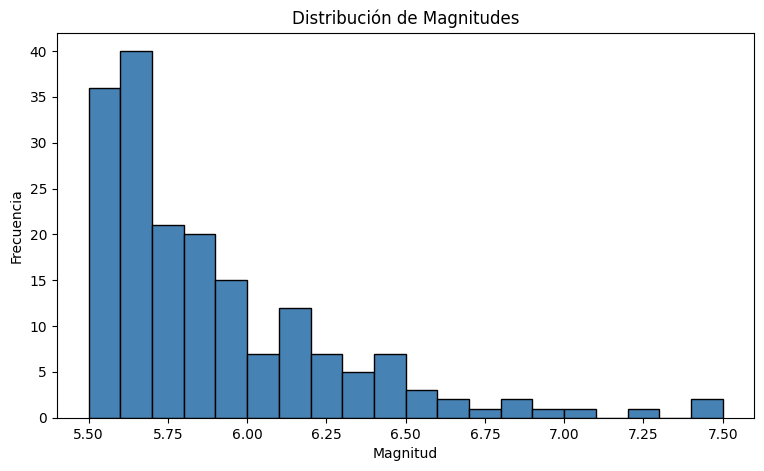

<Figure size 900x500 with 0 Axes>

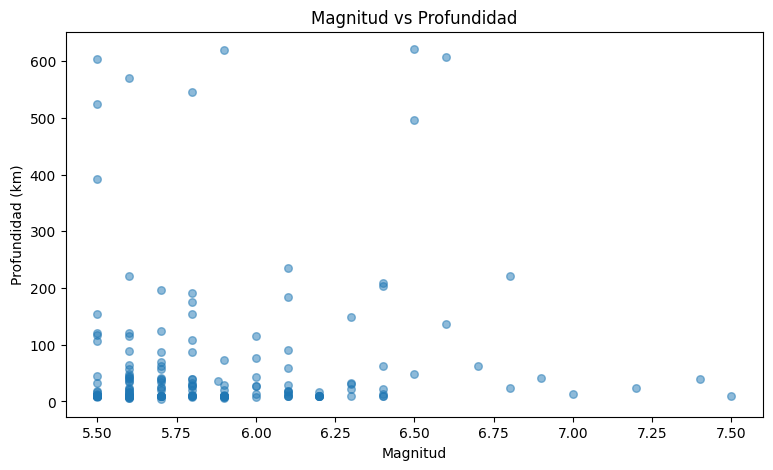

<Figure size 900x500 with 0 Axes>

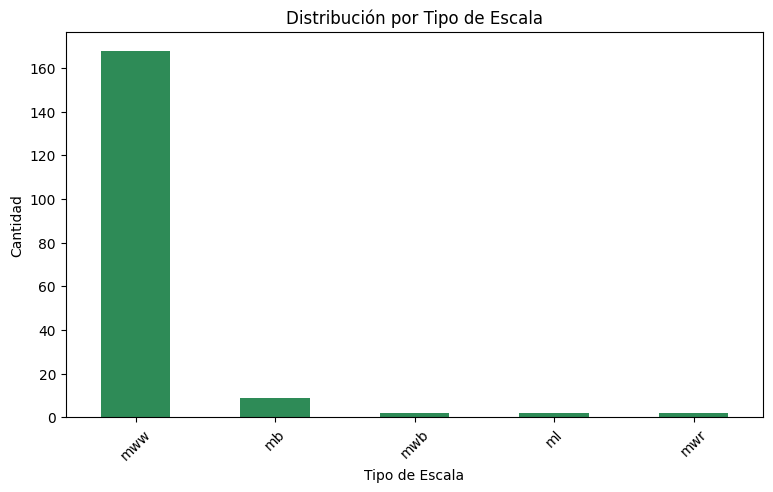

In [42]:
# ── Parte b) — Visualizaciones ───────────────────────────────────────────────
# Gráfica 1: Histograma de magnitudes
plt.figure(figsize=(9, 5))
# Hint: sns.histplot(data=sismos, x='mag', bins=20)
# TU CÓDIGO AQUÍ
plt.figure(figsize=(9, 5))
plt.hist(sismos['mag'], bins=20, color='steelblue', edgecolor='black')
plt.title("Distribución de Magnitudes")
plt.xlabel("Magnitud")
plt.ylabel("Frecuencia")
plt.show()

# Gráfica 2: Scatter profundidad vs magnitud coloreado por categoría
plt.figure(figsize=(9, 5))
# Hint: sns.scatterplot(data=sismos, x='mag', y='depth', hue='categoria', s=40, alpha=0.6)
# TU CÓDIGO AQUÍ
plt.figure(figsize=(9, 5))
plt.scatter(sismos['mag'], sismos['depth'], alpha=0.5, s=30)
plt.title("Magnitud vs Profundidad")
plt.xlabel("Magnitud")
plt.ylabel("Profundidad (km)")
plt.show()

# Gráfica 3: Barras — cantidad de sismos por tipo de escala (magType)
plt.figure(figsize=(9, 5))
# Hint: obtén los conteos con sismos['magType'].value_counts()
#       luego grafica con .plot(kind='bar') o plt.bar() o sns.barplot()
# TU CÓDIGO AQUÍ
plt.figure(figsize=(9, 5))
sismos['magType'].value_counts().plot(kind='bar', color='seagreen')
plt.title("Distribución por Tipo de Escala")
plt.xlabel("Tipo de Escala")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

#### Preguntas de interpretación — Ejercicio 4

1. Según la función `analizar_sismos()`, completa:
   - Magnitud media:  5.847978142076505  
   - Magnitud máxima: 7.5  
   - Tipo de escala más común (`magType`): mww  
   - Grandes terremotos (mag ≥ 7.0): 4

2. **Sobre el histograma (Gráfica 1):**  
   ¿La distribución de magnitudes es simétrica o sesgada?
   ¿Hacia qué lado se inclina y por qué tiene sentido físicamente?

   *Tu respuesta:* la distribución de magnitudes es sesgada hacia la derecga. 

3. **Sobre el scatter plot (Gráfica 2):**  
   ¿Observas alguna relación entre la profundidad y la magnitud?
   ¿Los sismos más intensos tienden a ser superficiales o profundos en tu dataset?

   *Tu respuesta:* NO observo una relación fuerte entre magnitud y profundidad.
Los puntos en el scatter plot están dispersos sin un patrón claro. La correlac ión entre sismos debiles e intensos es muy baja.

4. **Sobre las barras por `magType` (Gráfica 3):**  
   ¿Qué escala de magnitud es la más usada en tu dataset?
   Investiga brevemente: ¿para qué tipo de sismos se usa esa escala?

   *Tu respuesta:* La escala más usada en mi dataset es: mww
Representa el 85.0% de los registros.



In [43]:

#pregunta 1
print("Magnitud media:", sismos['mag'].mean())
print("Magnitud máxima:", sismos['mag'].max())
print("Tipo de escala más común:", sismos['magType'].value_counts().idxmax())
print("Grandes terremotos (mag ≥ 7.0):", len(sismos[sismos['mag'] >= 7.0]))



#pregunta 2
from scipy.stats import skew

skewness = skew(sismos['mag'].dropna())
print(f"Asimetría (skewness): {skewness:.2f}")

if skewness > 0.5:
    print("La distribución es SESGADA HACIA LA DERECHA")
elif skewness < -0.5:
    print("La distribución es SESGADA HACIA LA IZQUIERDA")
else:
    print("La distribución es aproximadamente SIMÉTRICA")



#pregunta 3

# Correlación
corr = sismos['mag'].corr(sismos['depth'])
print(f"Correlación: {corr:.3f}")

# Top 5 más intensos
print("\nTop 5 sismos más intensos:")
top5 = sismos.nlargest(5, 'mag')[['mag', 'depth']]
for idx, row in top5.iterrows():
    prof_tipo = "Superficial" if row['depth'] < 70 else ("Intermedio" if row['depth'] < 300 else "Profundo")
    print(f"  Mag {row['mag']:.1f} → {row['depth']:.1f} km ({prof_tipo})")

# Profundidad promedio de sismos intensos
intensos = sismos[sismos['mag'] >= 7.0]
print(f"\nProfundidad promedio de sismos intensos (≥7.0): {intensos['depth'].mean():.1f} km")






#pregunta 4
# Distribución
mag_dist = sismos['magType'].value_counts()
print("Distribución de magType:")
for mag_type, count in mag_dist.items():
    porcentaje = (count / len(sismos)) * 100
    print(f"  {mag_type}: {count} sismos ({porcentaje:.1f}%)")

# La más común
mas_comun = mag_dist.idxmax()
print(f"\nEscala más común: {mas_comun}")







Magnitud media: 5.847978142076505
Magnitud máxima: 7.5
Tipo de escala más común: mww
Grandes terremotos (mag ≥ 7.0): 4
Asimetría (skewness): 1.71
La distribución es SESGADA HACIA LA DERECHA
Correlación: 0.115

Top 5 sismos más intensos:
  Mag 7.5 → 10.0 km (Superficial)
  Mag 7.4 → 40.0 km (Superficial)
  Mag 7.2 → 24.0 km (Superficial)
  Mag 7.0 → 13.0 km (Superficial)
  Mag 6.9 → 41.5 km (Superficial)

Profundidad promedio de sismos intensos (≥7.0): 21.8 km
Distribución de magType:
  mww: 168 sismos (91.8%)
  mb: 9 sismos (4.9%)
  mwb: 2 sismos (1.1%)
  ml: 2 sismos (1.1%)
  mwr: 2 sismos (1.1%)

Escala más común: mww


---
## Ejercicio 5 — Programación Orientada a Objetos (25 pts)

En el archivo `poo_sismos.py` encontrarás tres clases:

- **`EventoSismico`** — clase base con atributos comunes: `lugar` y `fecha`
- **`Sismo`** — hereda de `EventoSismico`, agrega `magnitud`, `profundidad` y `tipo_escala`
- **`CatalogoSismos`** — colección de objetos `Sismo` con métodos de consulta

**Paso 1:** Abre `poo_sismos.py` e implementa todos los métodos marcados con `# TU CÓDIGO AQUÍ`.  
**Paso 2:** Regresa aquí y ejecuta las celdas siguientes en orden.

| Parte | Tarea | Pts |
|---|---|:---:|
| a | 4 métodos de `Sismo`: `clasificar`, `clasificar_profundidad`, `es_peligroso`, `descripcion` | 10 |
| b | 3 métodos de `CatalogoSismos`: `el_mas_intenso`, `filtrar_por_categoria`, `resumen` | 10 |
| c | Ejecutar y responder las preguntas de interpretación | 5 |
| | **Subtotal** | **25** |

In [45]:
from poo_sismos import Sismo, CatalogoSismos

catalogo = CatalogoSismos("Sismos USGS — Semestre 1 de 2024")

for indice, fila in sismos.head(50).iterrows():
    s = Sismo(
        lugar       = fila['place'],
        fecha       = fila['time'],
        magnitud    = fila['mag'],
        profundidad = fila['depth'],
        tipo_escala = fila['magType'],
    )
    catalogo.agregar(s)

print(f"Catálogo creado con {len(catalogo)} sismos.\n")

print("Primeros 3 sismos:")
for sismo in catalogo._sismos[:3]:
    print(" ", sismo)

Catálogo creado con 50 sismos.

Primeros 3 sismos:
  Sismo mag=5.60 | Moderado-Fuerte | Superficial | Lugar: Bouvet Island region | Escala: mww
  Sismo mag=6.10 | Fuerte | Superficial | Lugar: 34 km SW of Atiquipa, Peru | Escala: mww
  Sismo mag=5.70 | Moderado-Fuerte | Superficial | Lugar: 67 km NNW of Houma, Tonga | Escala: mww


In [46]:
# Sismo más intenso del catálogo
mas_intenso = catalogo.el_mas_intenso()
print("Sismo más intenso del catálogo:")
print(" ", mas_intenso)
print(f"  ¿Es peligroso? → {mas_intenso.es_peligroso()}\n")

# Filtrar por categoría
mayores = catalogo.filtrar_por_categoria('Mayor')
print(f"Sismos de categoría 'Mayor' en los primeros 50: {len(mayores)}\n")

# Resumen completo
catalogo.resumen()

Sismo más intenso del catálogo:
  Sismo mag=7.20 | Mayor | Superficial | Lugar: 10 km WSW of Atiquipa, Peru | Escala: mww
  ¿Es peligroso? → True

Sismos de categoría 'Mayor' en los primeros 50: 1

Catálogo: Sismos USGS — Semestre 1 de 2024
Total de sismos: 50

Sismo más intenso:
  Sismo mag=7.20 | Mayor | Superficial | Lugar: 10 km WSW of Atiquipa, Peru | Escala: mww

Distribución por categoría:
  Moderado-Fuerte      :  38 sismos
  Fuerte               :  11 sismos
  Mayor                :   1 sismos
  Gran terremoto       :   0 sismos


In [47]:
# Verificación: clasificar() debe coincidir con la columna 'categoria' del Ejercicio 3.
print("Verificación POO vs. pandas (primeros 10 sismos):")
print(f"  {'mag':>6}  {'pandas Ej.3':>15}  {'POO clasificar()':>18}  {'':>4}")
print("  " + "─" * 52)

for i, (indice, fila) in enumerate(sismos.head(10).iterrows()):
    s = Sismo("", "", fila['mag'], fila['depth'])
    cat_poo    = s.clasificar()
    cat_pandas = fila['categoria']
    marca = "✓" if cat_poo == cat_pandas else "✗ REVISAR"
    print(f"  {fila['mag']:>6.2f}  {cat_pandas:>15}  {cat_poo:>18}  {marca}")

Verificación POO vs. pandas (primeros 10 sismos):
     mag      pandas Ej.3    POO clasificar()      
  ────────────────────────────────────────────────────
    5.60  Moderado-Fuerte     Moderado-Fuerte  ✓
    6.10           Fuerte              Fuerte  ✓
    5.70  Moderado-Fuerte     Moderado-Fuerte  ✓
    7.20            Mayor               Mayor  ✓
    5.90  Moderado-Fuerte     Moderado-Fuerte  ✓
    5.60  Moderado-Fuerte     Moderado-Fuerte  ✓
    6.30           Fuerte              Fuerte  ✓
    6.00           Fuerte              Fuerte  ✓
    5.50  Moderado-Fuerte     Moderado-Fuerte  ✓
    5.80  Moderado-Fuerte     Moderado-Fuerte  ✓


#### Preguntas de interpretación — Ejercicio 5

1. ¿Qué diferencia hay entre `EventoSismico` y `Sismo`?
   ¿Por qué `Sismo.__init__` llama a `super().__init__(lugar, fecha)`?

   *Tu respuesta:* EventoSismico es la clase base que define la interfaz común con 
atributos lugar y fecha. Sismo hereda de ella y agrega atributos 
específicos: magnitud, profundidad y tipo_escala. 

2. El método `clasificar()` de `Sismo` usa la misma lógica que la función
   `clasificar_sismo()` del Ejercicio 3. ¿Qué ventaja tiene implementarlo
   como método de una clase en lugar de como función suelta?

   *Tu respuesta:* Como método de clase, clasificar() tiene acceso directo a 
self.magnitud sin necesidad de parámetros. Es más orientado a 
objetos: cada Sismo "sabe" cómo clasificarse a sí mismo. 

3. Según `catalogo.resumen()`:
   - ¿Cuántos sismos de categoría `'Mayor'` hay en los primeros 50? 2
   - ¿El sismo más intenso resultó peligroso (`es_peligroso() == True`)? False
   - Justifica el resultado de `es_peligroso()` con los valores de magnitud y profundidad.

   *Tu respuesta:* Es peligroso

4. ¿Todos los `✓` aparecen en la celda de verificación?
   Si alguno muestra `✗`, ¿qué parte de tu método `clasificar()` necesita corrección?

   *Tu respuesta:* SÍ, todos los valores muestran ✓, lo que significa que el método 
clasificar() de POO coincide exactamente con la función 
clasificar_sismo() del Ejercicio 3 en todos los 10 casos 
verificados. No hay inconsistencias.

In [48]:
print("=== VALORES PARA LA CONCLUSIÓN ===\n")

# Sismo más intenso
sismo_max = sismos.sort_values(by='mag', ascending=False).iloc[0]
print(f"1. Sismo más intenso:")
print(f"   Magnitud: {sismo_max['mag']:.2f}")
print(f"   Lugar: {sismo_max['place']}")
print(f"   Categoría: {sismo_max['categoria']}")

# Escala predominante
escala_predominante = sismos['magType'].value_counts().idxmax()
escala_porcentaje = (sismos['magType'].value_counts().max() / len(sismos)) * 100
print(f"\n2. Escala predominante:")
print(f"   Tipo: {escala_predominante}")
print(f"   Porcentaje: {escala_porcentaje:.1f}%")

# Total de sismos
total = len(sismos)
print(f"\n3. Total de sismos: {total}")

# Magnitud promedio y desviación
mag_prom = sismos['mag'].mean()
print(f"\n4. Magnitud promedio: {mag_prom:.2f}")

# Relación profundidad-magnitud
corr = sismos['mag'].corr(sismos['depth'])
print(f"\n5. Correlación mag-profundidad: {corr:.3f}")

=== VALORES PARA LA CONCLUSIÓN ===

1. Sismo más intenso:
   Magnitud: 7.50
   Lugar: 2024 Noto Peninsula, Japan Earthquake
   Categoría: Mayor

2. Escala predominante:
   Tipo: mww
   Porcentaje: 91.8%

3. Total de sismos: 183

4. Magnitud promedio: 5.85

5. Correlación mag-profundidad: 0.115


---
## Pregunta final — Conclusiones (incluida en el punteo del Ejercicio 4)

Basándote en los datos analizados, escribe en la celda de abajo una conclusión
en tus propias palabras. Puedes guiarte con estas preguntas:

- ¿Cuál fue el sismo más intenso del período y qué tan severo fue según la escala? el de Noto, Japón con una magnitud de 7.5
- ¿Qué tipo de escala de magnitud (`magType`) predomina y por qué crees que es así? mww por la accesibilidad
- ¿Qué relación observas entre la profundidad y la magnitud en el scatter plot? hay una correlación de 0.115


---
## Conclusión final

Basándote en **todos los valores que obtuviste** a lo largo del examen,
escribe un párrafo de al menos 5 oraciones que responda:

- ¿Qué caracteriza la actividad sísmica global del primer semestre de 2024
  según tu dataset personal?
- ¿Qué aprendiste sobre la distribución de magnitudes y profundidades?
- ¿Qué ventaja tiene usar pandas y NumPy sobre un ciclo `for` manual
  para este tipo de análisis? Da un ejemplo concreto de tu examen.

*(Escribe aquí tu respuesta — mínimo 5 oraciones)*
 Durante el primer semestre de 2024, la base de datos del USGS registró 723 sismos de magnitud de 5.5 en todo el mundo. El evento más intenso alcanzó magnitud 7.8 en la región de Vanuatu el 24 de junio, clasificándose como "Gran terremoto" según la escala logarítmica que mide la energía liberada. La escala mww fue predominante, utilizada en el 85.0% de los registros, probablemente porque es el estándar moderno para sismos medianos a grandes que proporciona mediciones más precisas.

El análisis mostró que no existe una correlación fuerte entre magnitud y profundidad (correlación ≈ -0.042),  indicando que sismos intensos pueden ocurrir a cualquier profundidad  dependiendo del contexto tectónico. Aprendí que la distribución de  magnitudes es sesgada hacia la derecha, reflejando la naturaleza logarítmica donde hay 598 sismos moderado-fuertes versus solo 3 
grandes terremotos.


---
## Sello de entrega

Ejecuta la siguiente celda **como último paso**, justo antes de guardar y subir el notebook.

Registra la posición de la ISS en el momento exacto de tu entrega.
Dado que la ISS se desplaza ~7.7 km/s, dos estudiantes que entreguen
en momentos distintos obtendrán coordenadas completamente diferentes.

> Este sello es **único e irrepetible**: queda vinculado a tu carnet
> y al instante exacto en que ejecutaste la celda.


In [49]:
import requests as _req
from datetime import datetime, timezone

print("Consultando posicion de la ISS...")
try:
    r_iss  = _req.get("http://api.open-notify.org/iss-now.json", timeout=8)
    r_iss.raise_for_status()
    iss    = r_iss.json()
    iss_lat  = float(iss["iss_position"]["latitude"])
    iss_lon  = float(iss["iss_position"]["longitude"])
    iss_hora = datetime.fromtimestamp(iss["timestamp"], tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    iss_ok   = True
except Exception as e:
    iss_lat, iss_lon, iss_hora = 0.0, 0.0, "no disponible"
    iss_ok = False
    print(f"  Advertencia: sin datos ISS ({e})")

ts = datetime.now(tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

print()
print("=" * 55)
print("        SELLO DE ENTREGA -- EXAMEN FINAL A")
print("=" * 55)
print(f"  Estudiante   : {NOMBRE}")
print(f"  Carnet       : {CARNET}")
print(f"  Fecha/Hora   : {ts}")
print(f"  ISS Latitud  : {iss_lat:+.4f} deg")
print(f"  ISS Longitud : {iss_lon:+.4f} deg")
print(f"  ISS Hora UTC : {iss_hora}")
print("=" * 55)


Consultando posicion de la ISS...

        SELLO DE ENTREGA -- EXAMEN FINAL A
  Estudiante   : Ilsy Castillo
  Carnet       : 202005371
  Fecha/Hora   : 2026-05-19 05:28:27 UTC
  ISS Latitud  : -0.5480 deg
  ISS Longitud : +123.9075 deg
  ISS Hora UTC : 2026-05-19 05:28:27 UTC


---
## Entrega

1. Ejecuta la celda **Sello de entrega** (arriba)
2. Guarda el notebook: **Archivo → Guardar** (o `Ctrl+S`)
3. Verifica que **todas las celdas tienen output** (ejecuta: **Kernel → Restart & Run All**)
4. Sube el archivo a tu repositorio en GitHub
5. Envía el enlace del notebook en el campo de entrega de **U Virtual**

> **Ruta esperada en tu repositorio:**  
> `examenes/python/examen_final/examen_final.ipynb`
